In [47]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [48]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [49]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner='lmars23', repo_name='ml_assignment_1', mlflow=True)

Initialized MLflow to track repo "lmars23/ml_assignment_1"

Repository lmars23/ml_assignment_1 initialized!

In [50]:
print(mlflow.get_tracking_uri())

https://dagshub.com/lmars23/ml_assignment_1.mlflow


# Exploratory Data Analysis (EDA)

In [51]:
df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

In [52]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [53]:
df.shape

(1460, 81)

In [54]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [55]:
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (1168, 80)
Test size:  (292, 80)


In [56]:
train_ids = X_train.pop('Id')
test_ids = X_test.pop('Id')

In [57]:
y.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

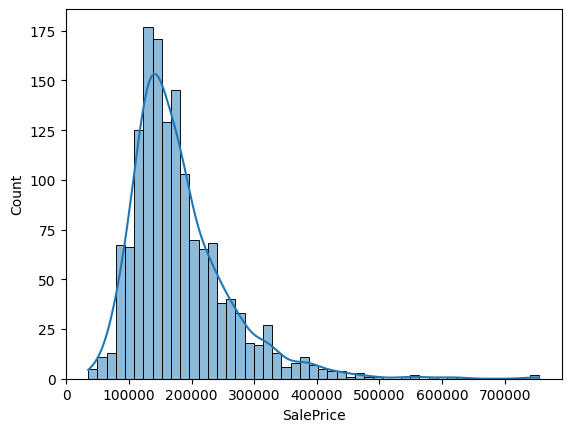

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["SalePrice"], kde=True)
plt.show()

In [59]:
missing = X_train.isnull().sum().sort_values(ascending=False)

missing

PoolQC           1162
MiscFeature      1122
Alley            1094
Fence             935
MasVnrType        683
                 ... 
MiscVal             0
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
Length: 79, dtype: int64

<Axes: >

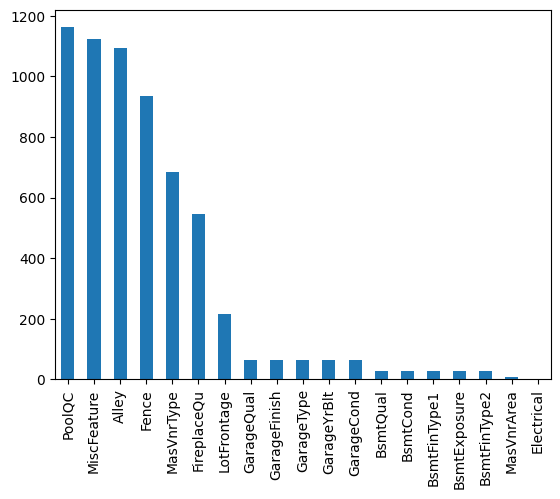

In [60]:
missing[missing > 0].plot(kind="bar")

In [61]:
missing_freq = X_train.isnull().mean() 
missing_freq[missing_freq > 0].sort_values(ascending=True)

Electrical      0.000856
MasVnrArea      0.005137
BsmtCond        0.023973
BsmtExposure    0.023973
BsmtFinType1    0.023973
BsmtQual        0.023973
BsmtFinType2    0.023973
GarageType      0.054795
GarageQual      0.054795
GarageFinish    0.054795
GarageCond      0.054795
GarageYrBlt     0.054795
LotFrontage     0.185788
FireplaceQu     0.468322
MasVnrType      0.584760
Fence           0.800514
Alley           0.936644
MiscFeature     0.960616
PoolQC          0.994863
dtype: float64

<Axes: >

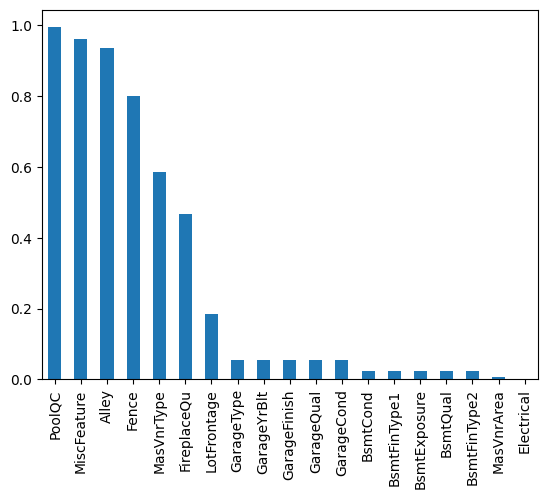

In [62]:
missing_freq[missing_freq > 0].sort_values(ascending=False).plot(kind="bar")

In [63]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageAre

In [64]:
missing_freq_num = X_train[num_cols].isnull().mean()
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True)

MasVnrArea     0.005137
GarageYrBlt    0.054795
LotFrontage    0.185788
dtype: float64

<Axes: >

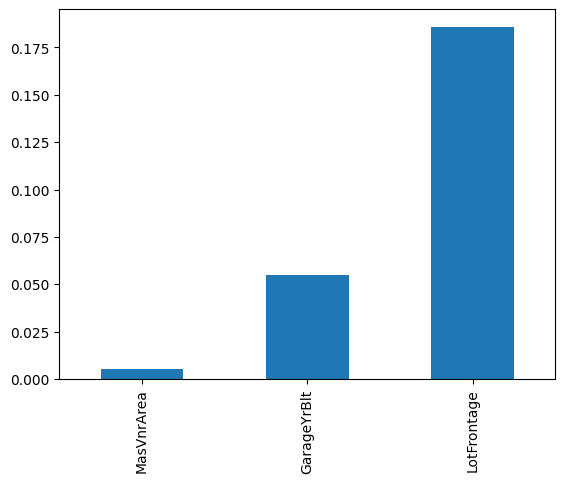

In [65]:
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True).plot(kind="bar")

In [66]:
X_train["MasVnrArea"]

254       0.0
1066      0.0
638       0.0
799     252.0
380       0.0
        ...  
1095      0.0
1130      0.0
1294      0.0
860       0.0
1126    130.0
Name: MasVnrArea, Length: 1168, dtype: float64

<Figure size 1500x1000 with 0 Axes>

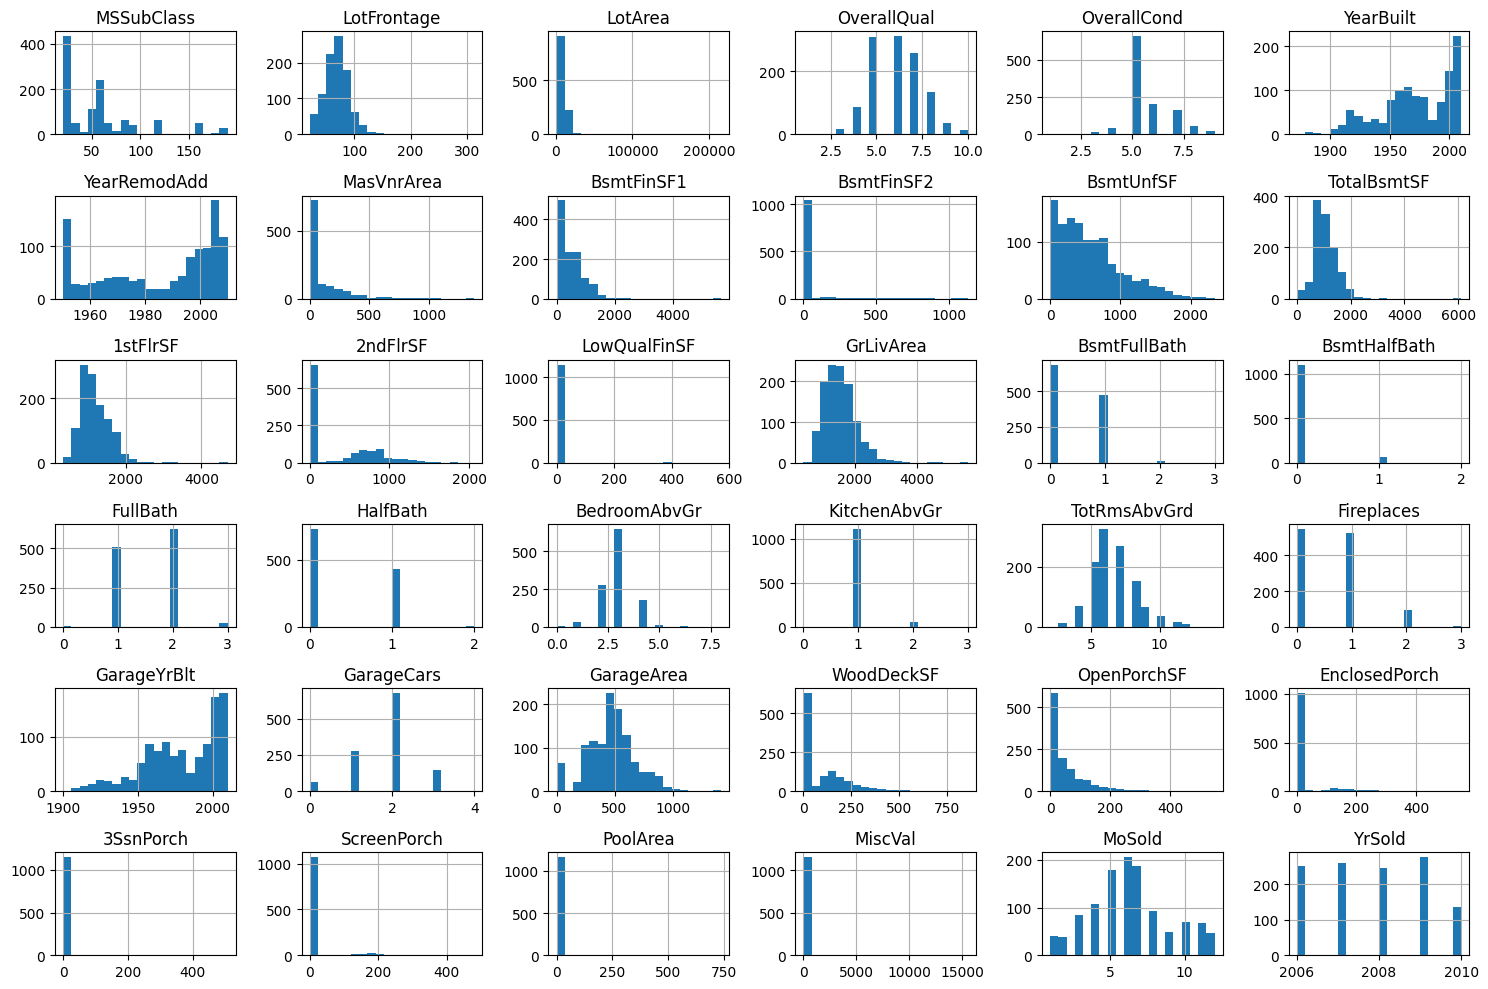

In [67]:
X_train[num_cols].describe()

plt.figure(figsize=(15, 10))
X_train[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Data Cleaning

In [68]:
X_train["MasVnrArea"] = X_train["MasVnrArea"].fillna(0)
X_test["MasVnrArea"] = X_test["MasVnrArea"].fillna(0)

median_GarageYrBlt = X_train["GarageYrBlt"].median()
X_train["GarageYrBlt"] = X_train["GarageYrBlt"].fillna(median_GarageYrBlt)
X_test["GarageYrBlt"] = X_test["GarageYrBlt"].fillna(median_GarageYrBlt)

median_LotFrontage = X_train["LotFrontage"].median()
X_train["LotFrontage"] = X_train["LotFrontage"].fillna(median_LotFrontage)
X_test["LotFrontage"] = X_test["LotFrontage"].fillna(median_LotFrontage)

In [70]:
missing_freq_num = X_train[num_cols].isnull().mean()
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True)

Series([], dtype: float64)

In [71]:
missing_freq_num = X_train[cat_cols].isnull().mean()
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True)

Electrical      0.000856
BsmtCond        0.023973
BsmtExposure    0.023973
BsmtQual        0.023973
BsmtFinType1    0.023973
BsmtFinType2    0.023973
GarageFinish    0.054795
GarageType      0.054795
GarageQual      0.054795
GarageCond      0.054795
FireplaceQu     0.468322
MasVnrType      0.584760
Fence           0.800514
Alley           0.936644
MiscFeature     0.960616
PoolQC          0.994863
dtype: float64

<Axes: >

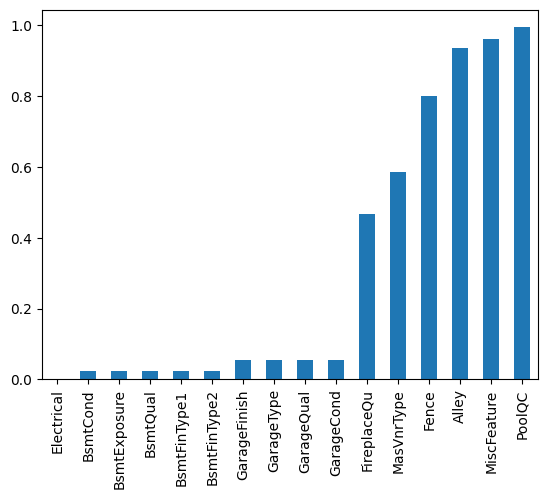

In [72]:
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True).plot(kind="bar")

In [73]:
print(cat_cols)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [74]:
ohe_cols = ["MSZoning", "Street", "Alley", "LotShape", "LandContour", "Utilities", "LotConfig", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", "CentralAir", "Electrical", "GarageType", "PavedDrive", "MiscFeature", "SaleType", "SaleCondition", "Neighborhood"]
ord_cols = ["LandSlope", "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual", "Functional", "FireplaceQu", "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence"]

In [75]:
quality_map = {
    "NA": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

quality_cols = [
    "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual", "GarageCond",
    "PoolQC"
]

for col in quality_cols:
    X_train[col] = X_train[col].fillna("NA").map(quality_map)
    X_test[col] = X_test[col].fillna("NA").map(quality_map)

In [76]:
ordinal_map_non_quality = {
    "BsmtExposure": {"NA":0, "No":1, "Mn":2, "Av":3, "Gd":4},

    "BsmtFinType1": {"NA":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},
    "BsmtFinType2": {"NA":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},

    "Functional": {
        "Sal":0, "Sev":1, "Maj2":2, "Maj1":3,
        "Mod":4, "Min2":5, "Min1":6, "Typ":7
    },

    "GarageFinish": {"NA":0, "Unf":1, "RFn":2, "Fin":3},

    "Fence": {"NA":0, "MnWw":1, "GdWo":2, "MnPrv":3, "GdPrv":4},

    "LandSlope": {"Gtl":0, "Mod":1, "Sev":2}
}

for col, mapping in ordinal_map_non_quality.items():
    X_train[col] = X_train[col].fillna("NA").map(mapping)
    X_test[col] = X_test[col].fillna("NA").map(mapping)

In [77]:
for col in ord_cols:
    print(X_train[col].value_counts(dropna=False).sort_index())

LandSlope
0    1108
1      51
2       9
Name: count, dtype: int64
ExterQual
2     11
3    727
4    388
5     42
Name: count, dtype: int64
ExterCond
1       1
2      24
3    1018
4     122
5       3
Name: count, dtype: int64
BsmtQual
0     28
2     29
3    521
4    493
5     97
Name: count, dtype: int64
BsmtCond
0      28
1       1
2      39
3    1045
4      55
Name: count, dtype: int64
BsmtExposure
0     28
1    769
2     93
3    175
4    103
Name: count, dtype: int64
BsmtFinType1
0     28
1    345
2     62
3    104
4    123
5    178
6    328
Name: count, dtype: int64
BsmtFinType2
0      28
1    1009
2      36
3      46
4      22
5      17
6      10
Name: count, dtype: int64
HeatingQC
1      1
2     42
3    347
4    195
5    583
Name: count, dtype: int64
KitchenQual
2     32
3    589
4    470
5     77
Name: count, dtype: int64
Functional
1       1
2       4
3       9
4      13
5      29
6      28
7    1084
Name: count, dtype: int64
FireplaceQu
0    547
1     16
2     27
3    252
4    3

MSZoning
RL         924
RM         172
FV          53
RH          15
C (all)      4
Name: count, dtype: int64


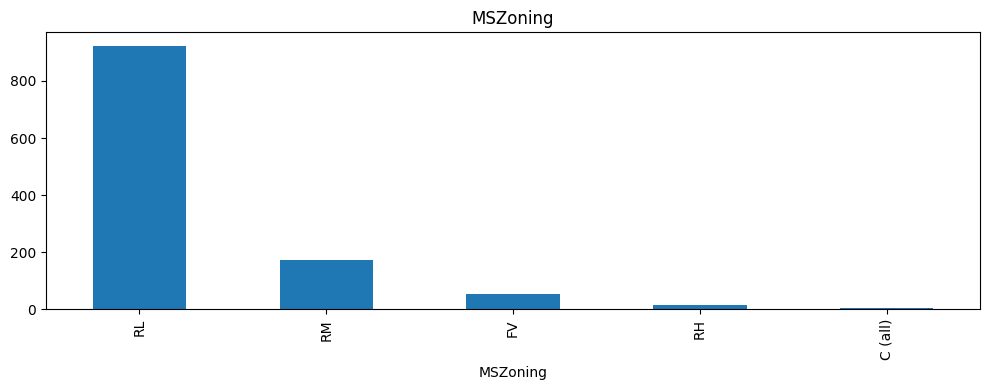

Street
Pave    1164
Grvl       4
Name: count, dtype: int64


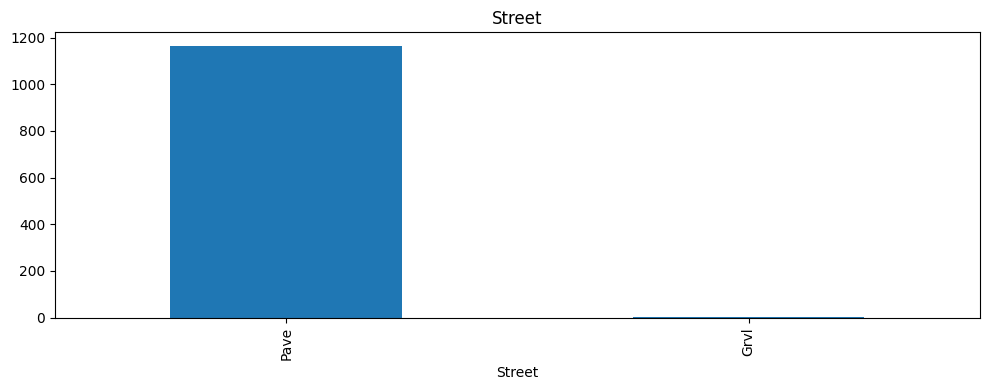

Alley
Grvl    44
Pave    30
Name: count, dtype: int64


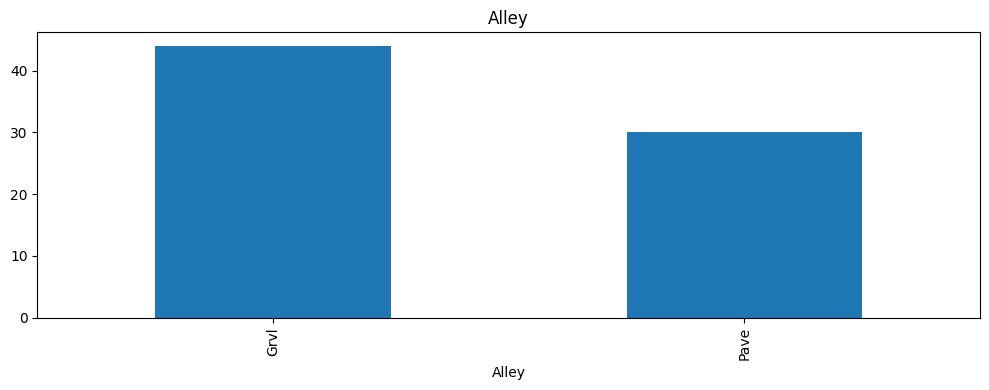

LotShape
Reg    729
IR1    394
IR2     37
IR3      8
Name: count, dtype: int64


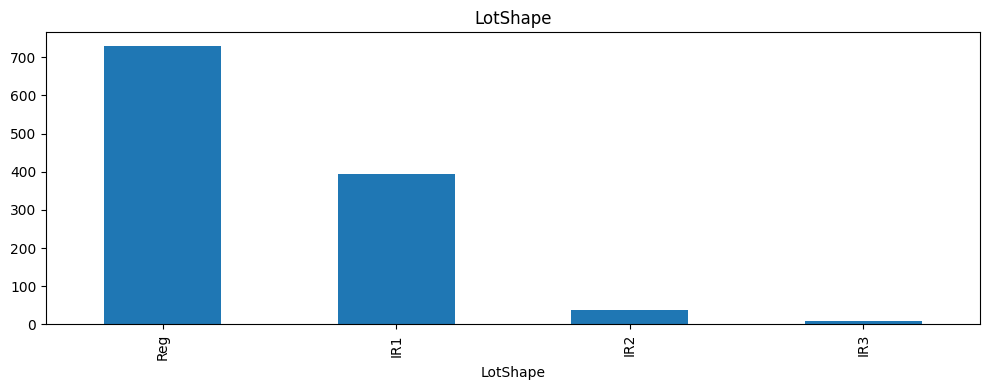

LandContour
Lvl    1059
Bnk      48
HLS      35
Low      26
Name: count, dtype: int64


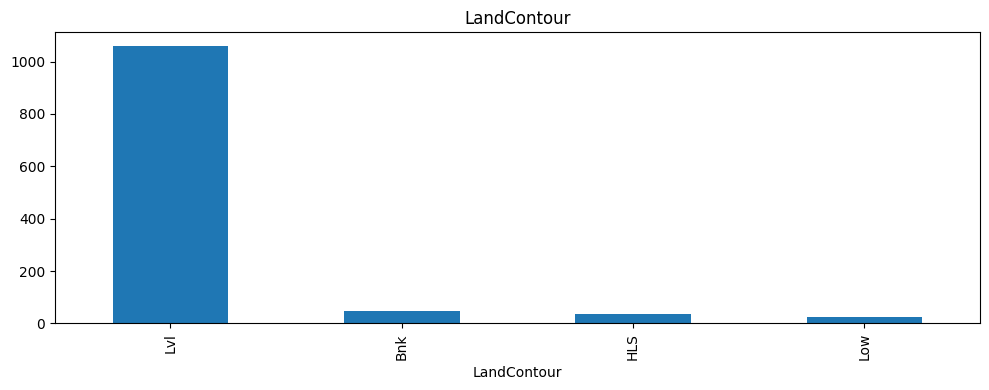

Utilities
AllPub    1167
NoSeWa       1
Name: count, dtype: int64


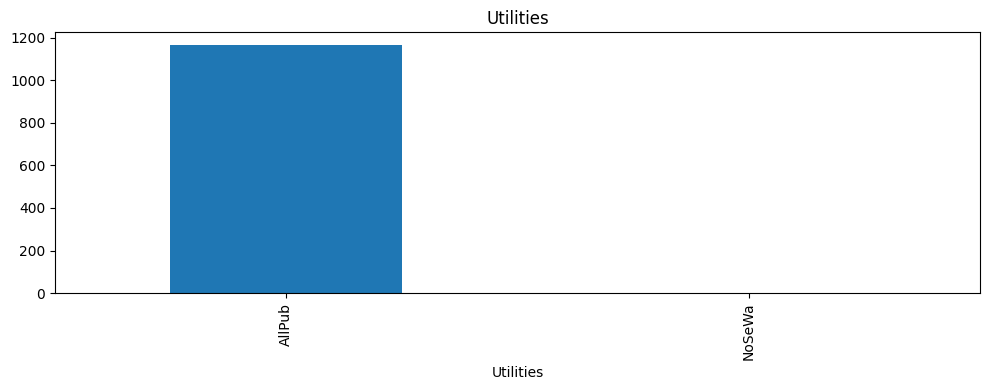

LotConfig
Inside     822
Corner     221
CulDSac     84
FR2         38
FR3          3
Name: count, dtype: int64


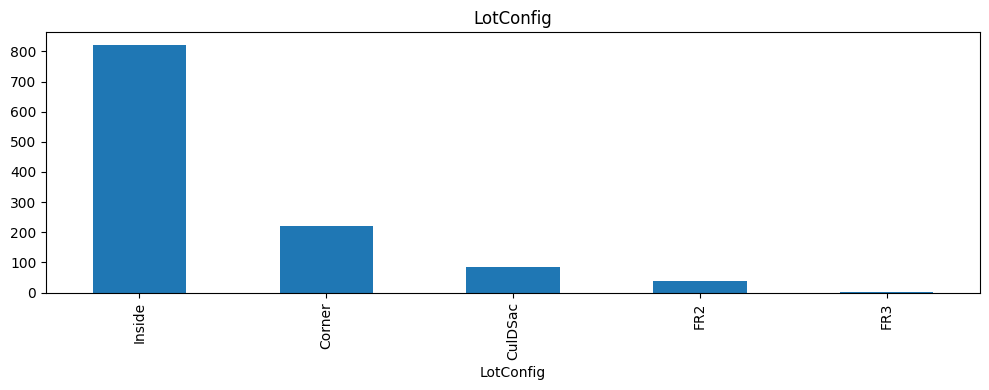

LandSlope
0    1108
1      51
2       9
Name: count, dtype: int64


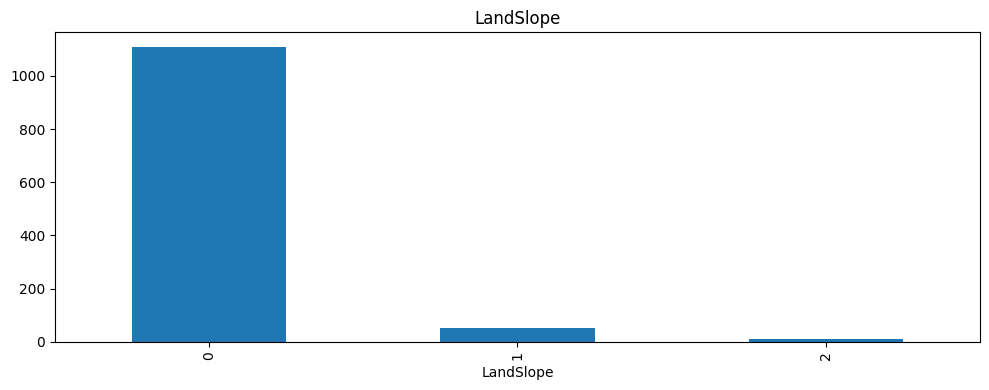

Neighborhood
NAmes      181
CollgCr    115
OldTown     91
Edwards     87
Somerst     69
NWAmes      66
Gilbert     65
NridgHt     61
Sawyer      58
BrkSide     45
Crawfor     44
SawyerW     44
Mitchel     40
NoRidge     33
Timber      28
IDOTRR      26
SWISU       21
StoneBr     20
ClearCr     19
Blmngtn     15
BrDale      13
MeadowV     10
Veenker      9
NPkVill      7
Blueste      1
Name: count, dtype: int64


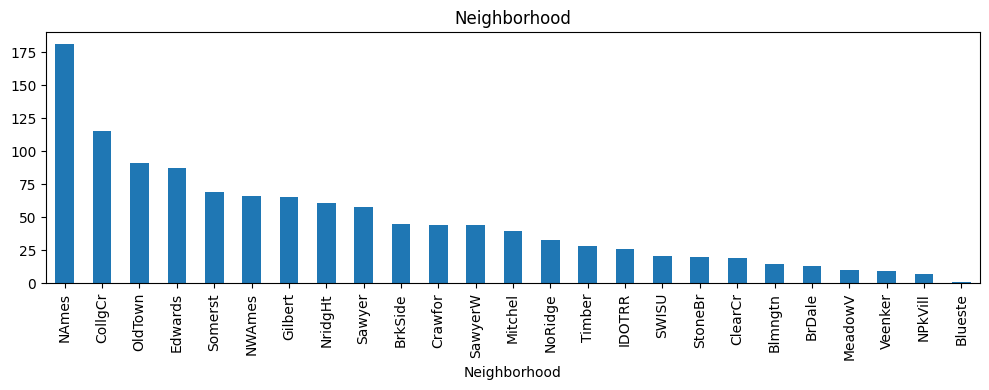

Condition1
Norm      1004
Feedr       66
Artery      40
RRAn        19
PosN        15
RRAe        10
PosA         8
RRNn         5
RRNe         1
Name: count, dtype: int64


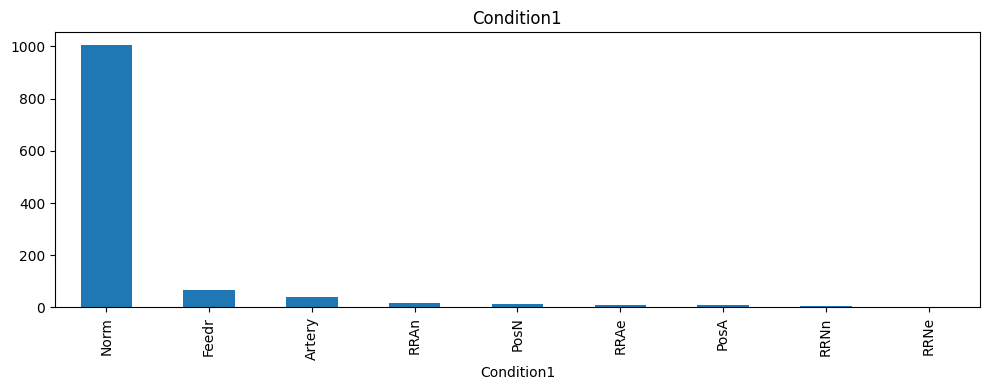

Condition2
Norm      1157
Feedr        3
Artery       2
PosN         2
PosA         1
RRNn         1
RRAe         1
RRAn         1
Name: count, dtype: int64


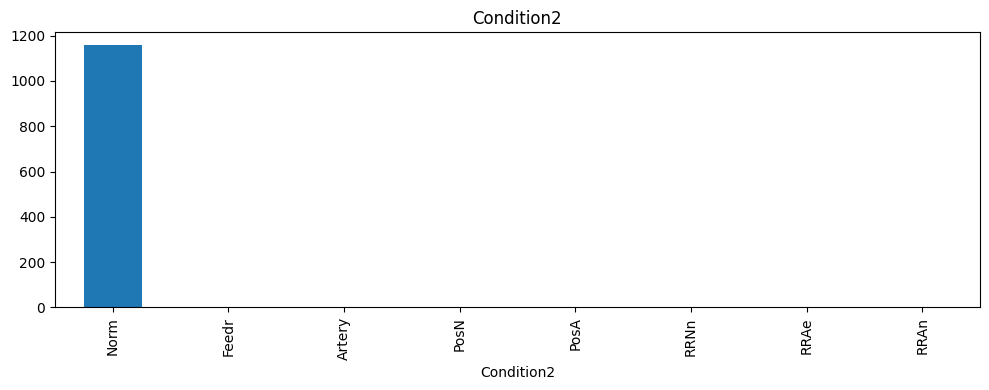

BldgType
1Fam      978
TwnhsE     88
Duplex     41
Twnhs      32
2fmCon     29
Name: count, dtype: int64


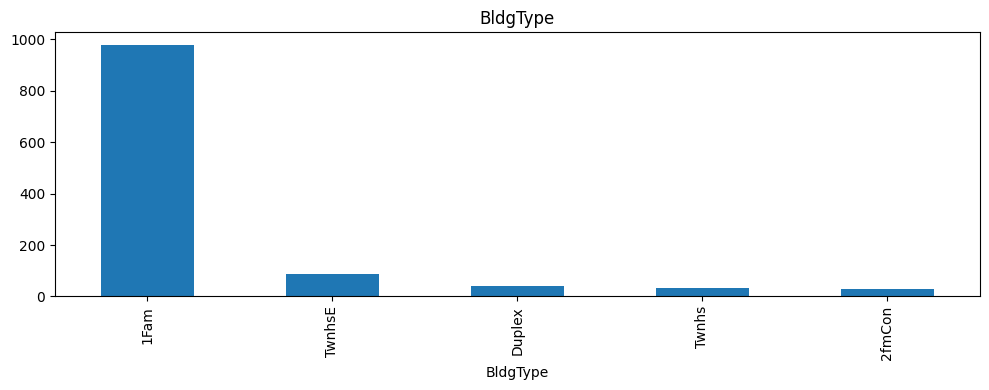

HouseStyle
1Story    577
2Story    360
1.5Fin    121
SLvl       52
SFoyer     28
1.5Unf     12
2.5Unf     11
2.5Fin      7
Name: count, dtype: int64


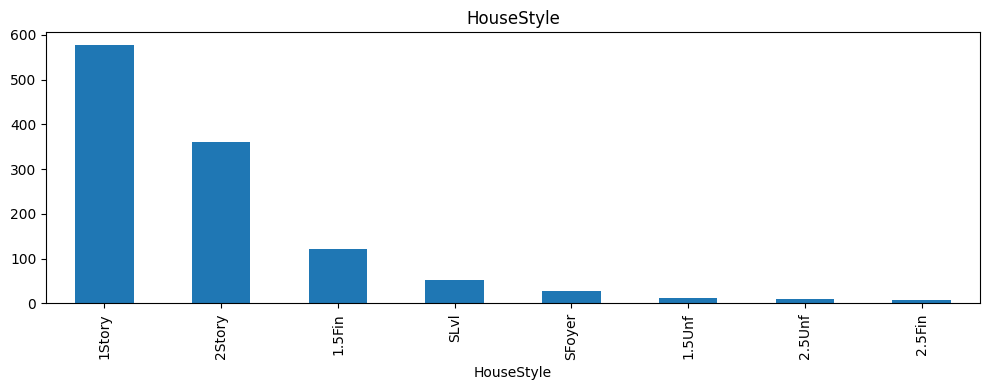

RoofStyle
Gable      906
Hip        235
Flat        11
Gambrel      9
Mansard      5
Shed         2
Name: count, dtype: int64


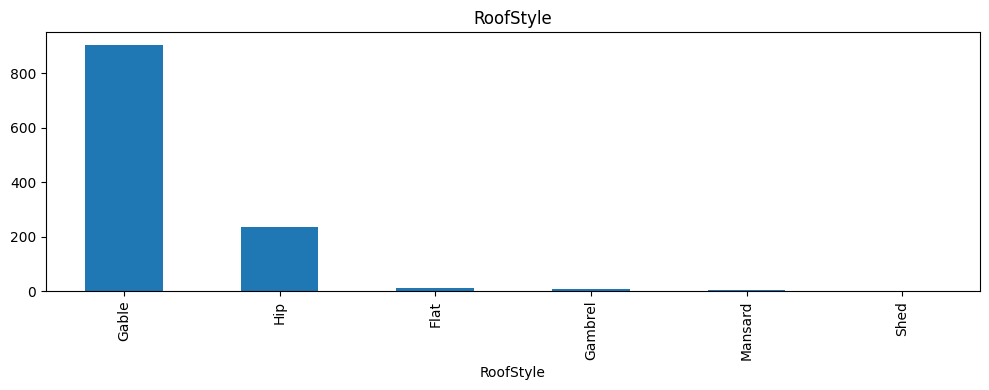

RoofMatl
CompShg    1149
Tar&Grv       9
WdShngl       4
WdShake       3
Metal         1
ClyTile       1
Roll          1
Name: count, dtype: int64


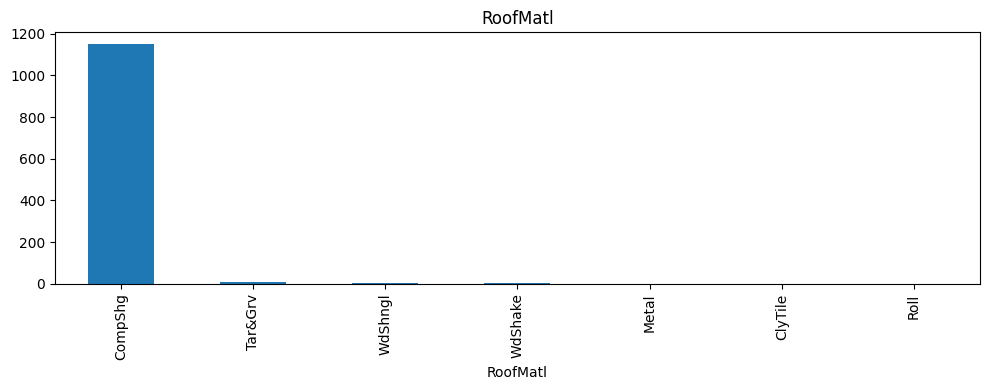

Exterior1st
VinylSd    420
HdBoard    176
MetalSd    173
Wd Sdng    171
Plywood     81
CemntBd     45
BrkFace     40
Stucco      21
WdShing     19
AsbShng     16
BrkComm      2
ImStucc      1
CBlock       1
AsphShn      1
Stone        1
Name: count, dtype: int64


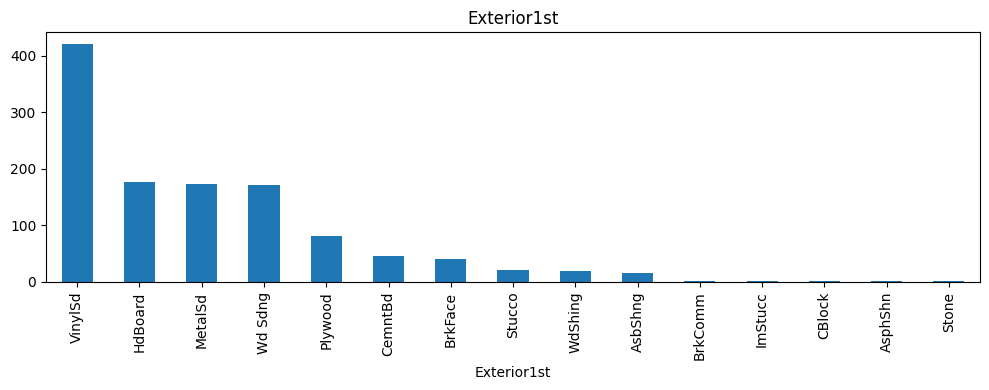

Exterior2nd
VinylSd    410
MetalSd    165
Wd Sdng    165
HdBoard    163
Plywood    112
CmentBd     44
Wd Shng     34
Stucco      23
AsbShng     17
BrkFace     15
ImStucc      6
Brk Cmn      6
AsphShn      3
Stone        3
Other        1
CBlock       1
Name: count, dtype: int64


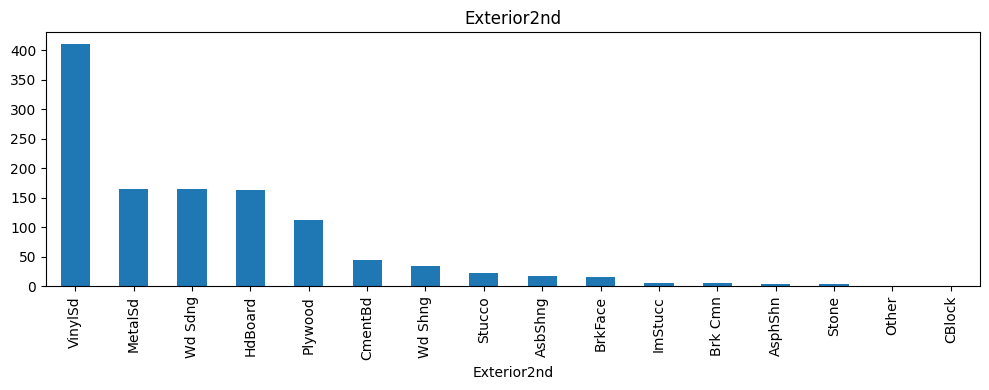

MasVnrType
BrkFace    366
Stone      106
BrkCmn      13
Name: count, dtype: int64


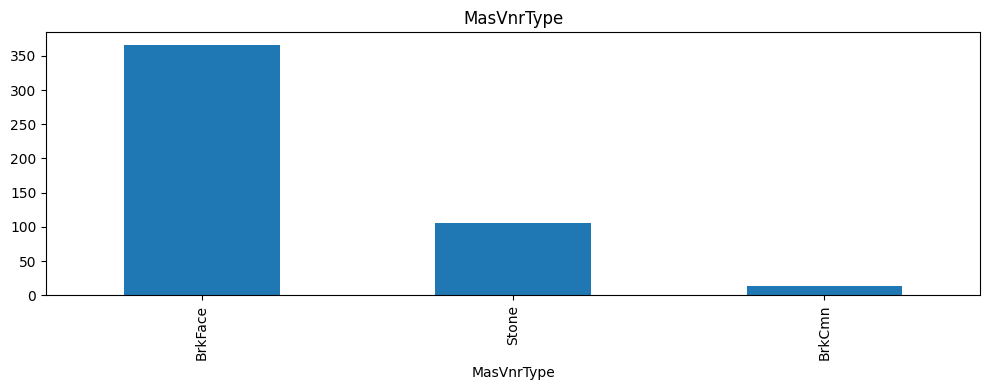

ExterQual
3    727
4    388
5     42
2     11
Name: count, dtype: int64


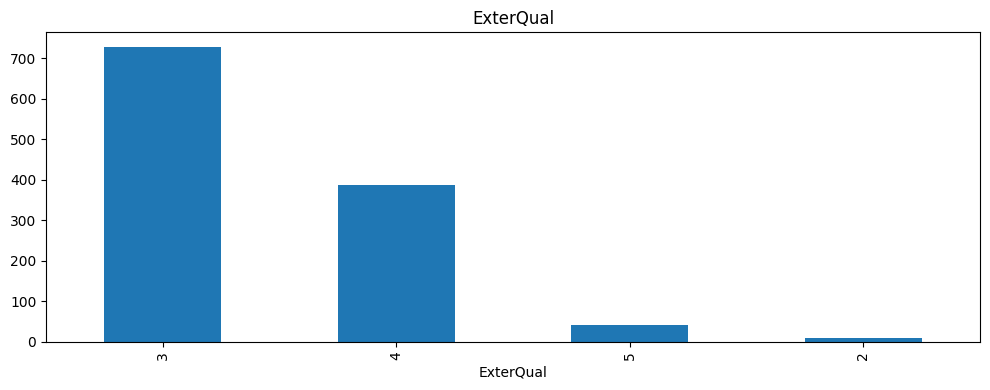

ExterCond
3    1018
4     122
2      24
5       3
1       1
Name: count, dtype: int64


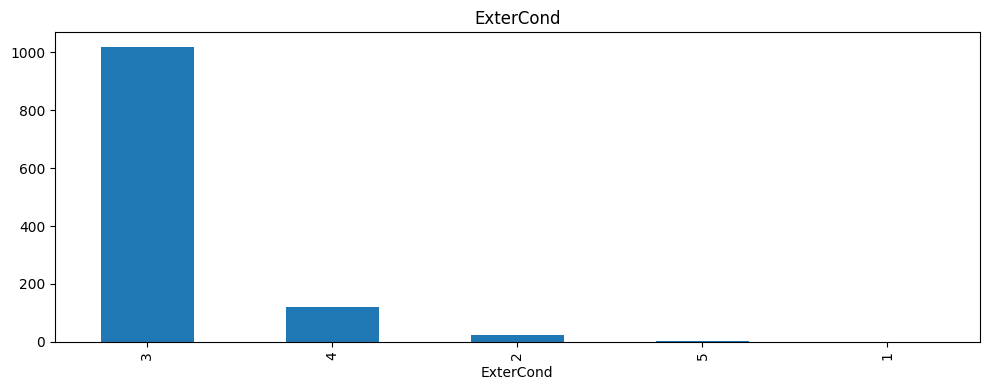

Foundation
PConc     520
CBlock    504
BrkTil    116
Slab       20
Stone       5
Wood        3
Name: count, dtype: int64


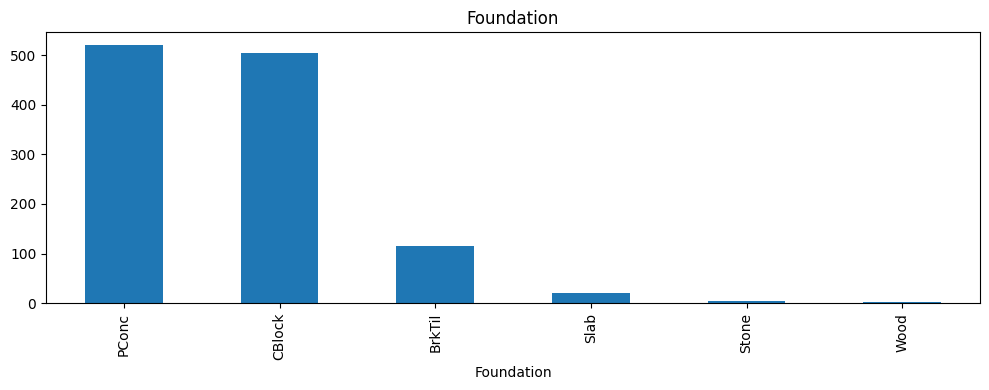

BsmtQual
3    521
4    493
5     97
2     29
0     28
Name: count, dtype: int64


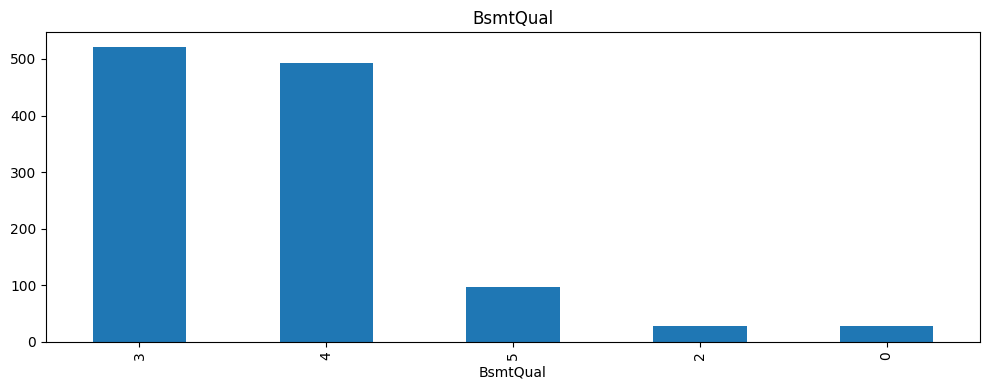

BsmtCond
3    1045
4      55
2      39
0      28
1       1
Name: count, dtype: int64


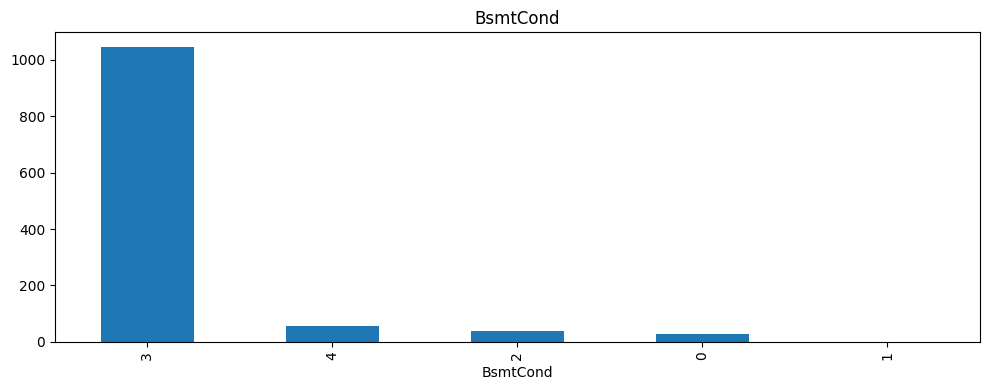

BsmtExposure
1    769
3    175
4    103
2     93
0     28
Name: count, dtype: int64


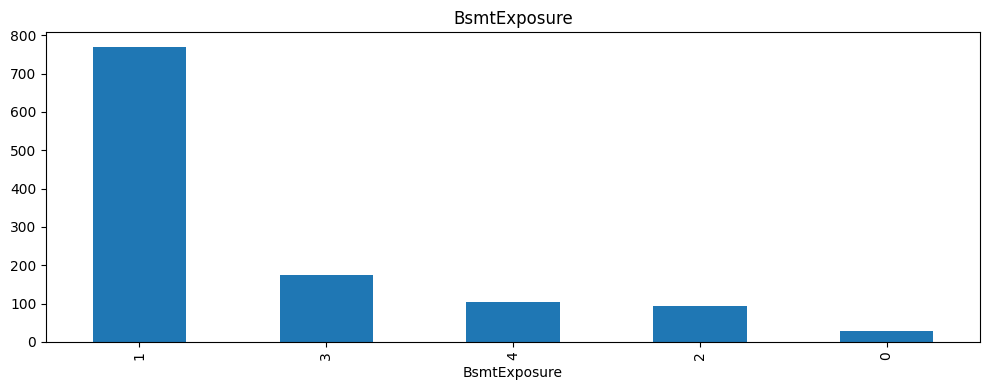

BsmtFinType1
1    345
6    328
5    178
4    123
3    104
2     62
0     28
Name: count, dtype: int64


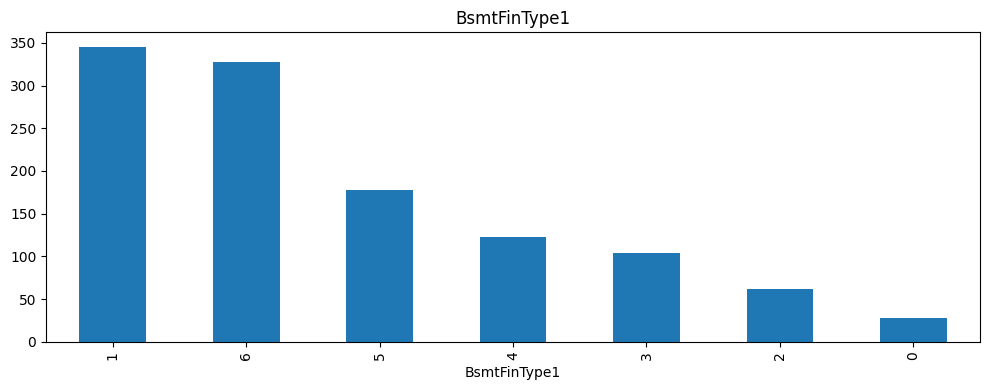

BsmtFinType2
1    1009
3      46
2      36
0      28
4      22
5      17
6      10
Name: count, dtype: int64


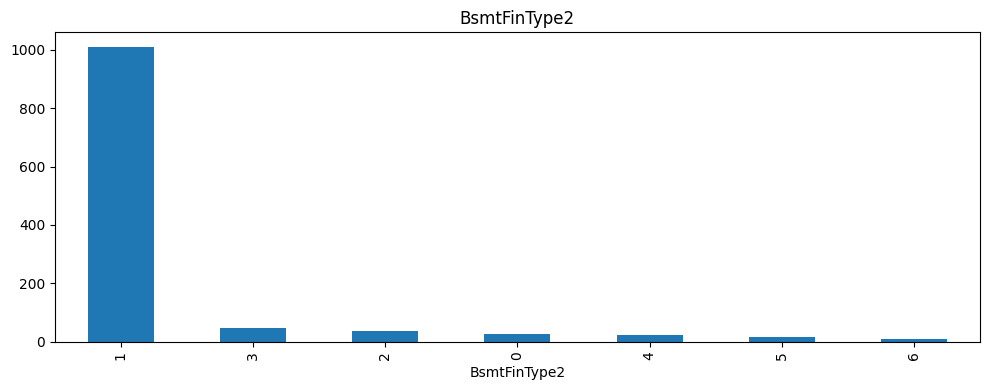

Heating
GasA     1140
GasW       15
Grav        6
Wall        4
OthW        2
Floor       1
Name: count, dtype: int64


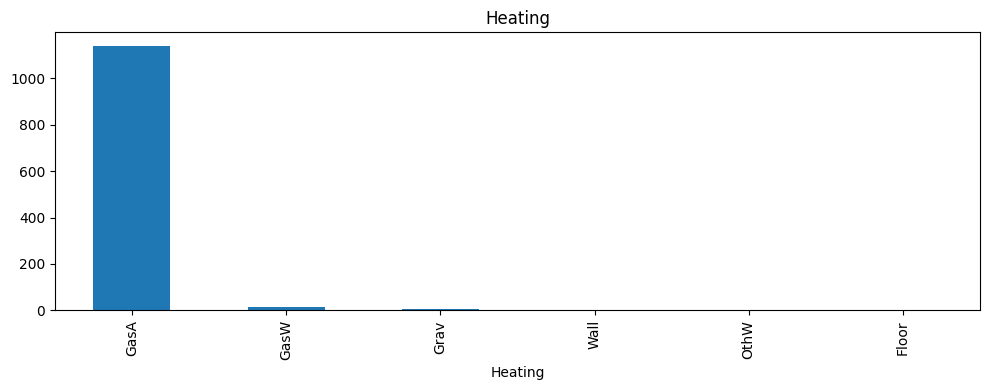

HeatingQC
5    583
3    347
4    195
2     42
1      1
Name: count, dtype: int64


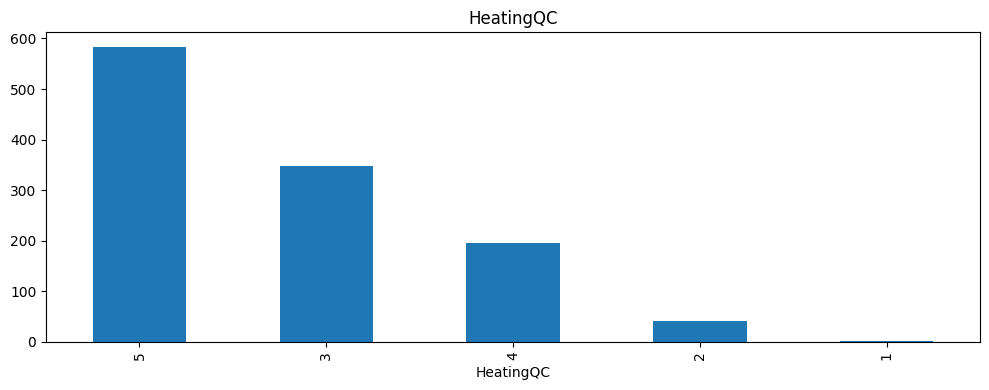

CentralAir
Y    1085
N      83
Name: count, dtype: int64


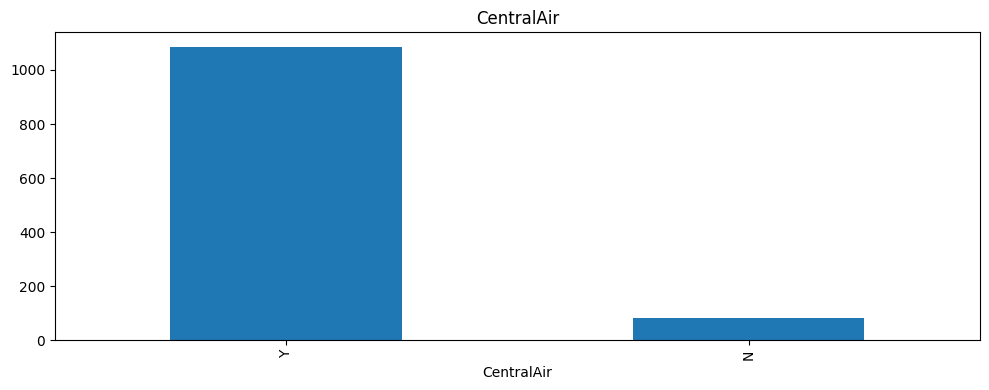

Electrical
SBrkr    1071
FuseA      69
FuseF      24
FuseP       3
Name: count, dtype: int64


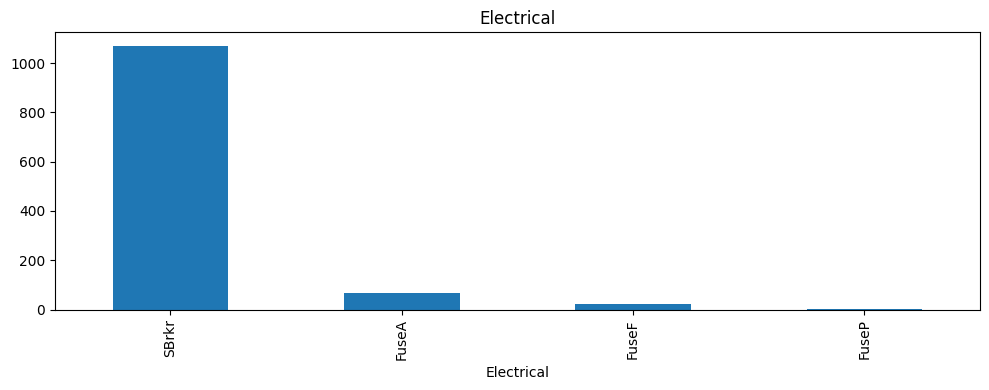

KitchenQual
3    589
4    470
5     77
2     32
Name: count, dtype: int64


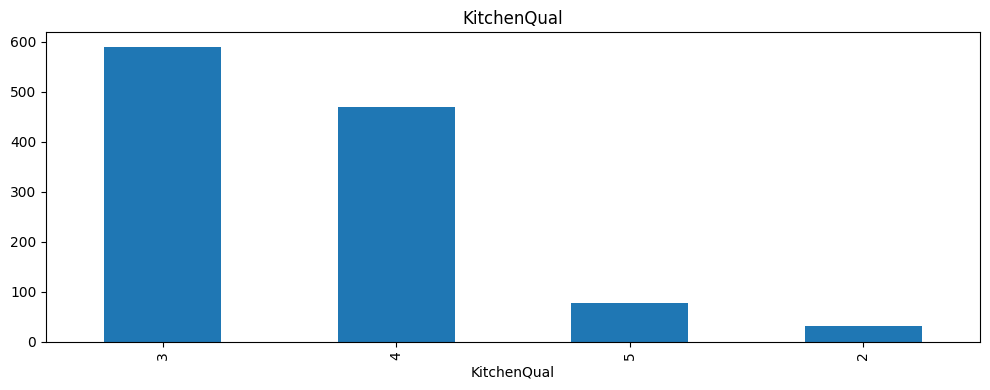

Functional
7    1084
5      29
6      28
4      13
3       9
2       4
1       1
Name: count, dtype: int64


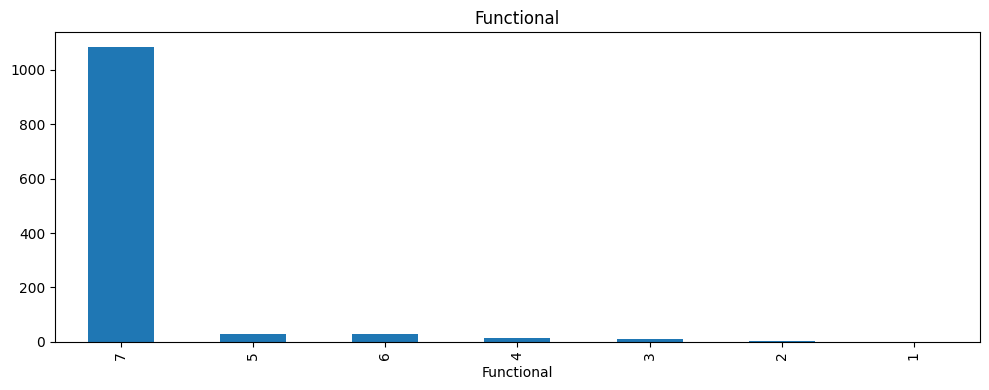

FireplaceQu
0    547
4    305
3    252
2     27
5     21
1     16
Name: count, dtype: int64


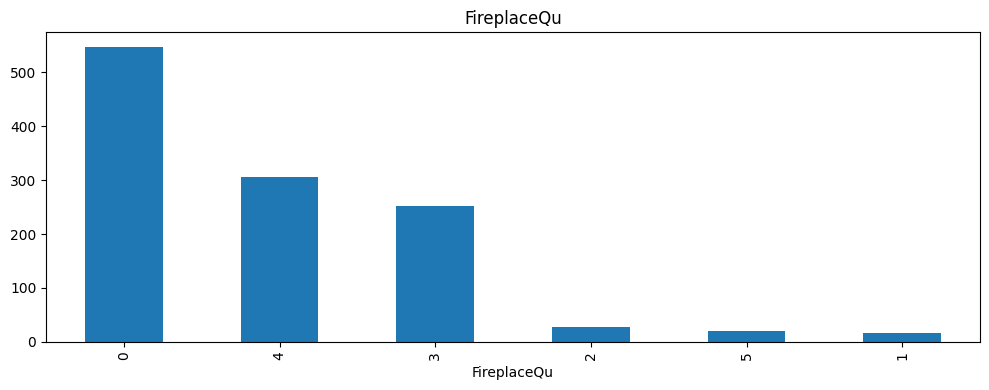

GarageType
Attchd     693
Detchd     308
BuiltIn     74
Basment     16
CarPort      7
2Types       6
Name: count, dtype: int64


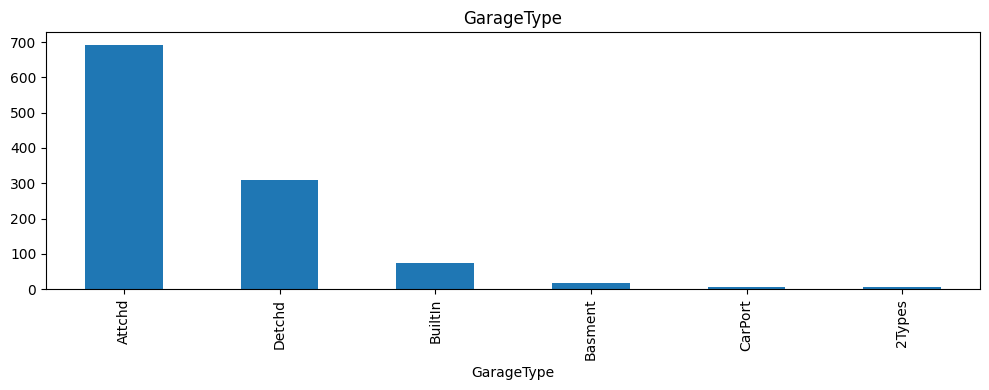

GarageFinish
1    480
2    339
3    285
0     64
Name: count, dtype: int64


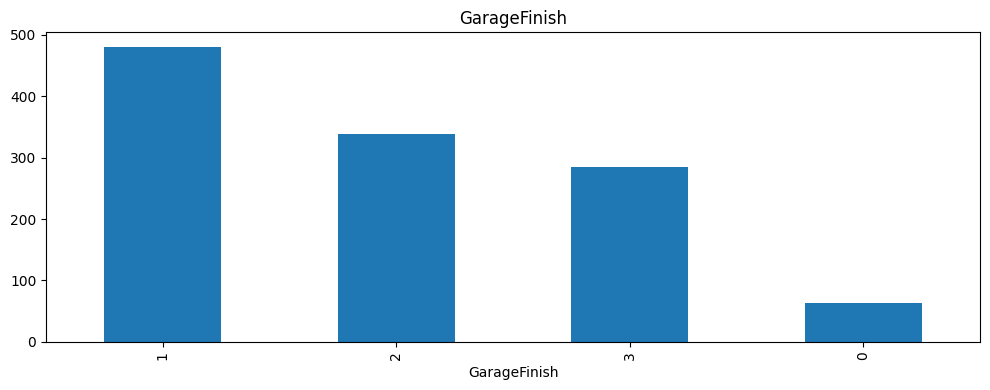

GarageQual
3    1050
0      64
2      36
4      13
5       3
1       2
Name: count, dtype: int64


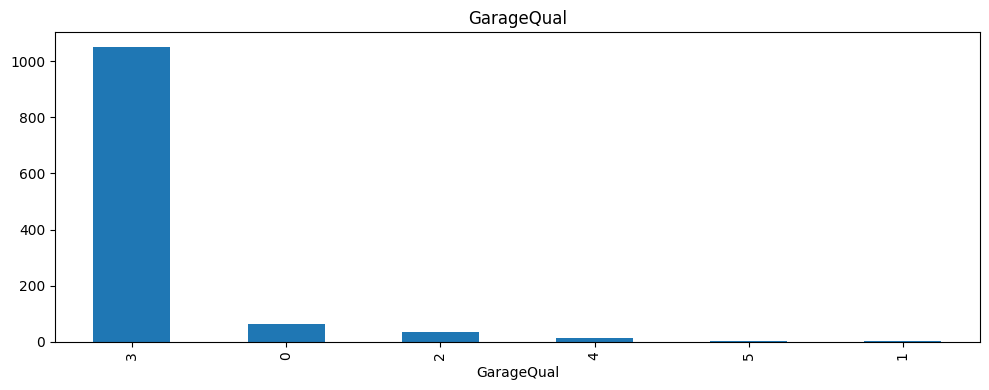

GarageCond
3    1061
0      64
2      27
4       9
1       5
5       2
Name: count, dtype: int64


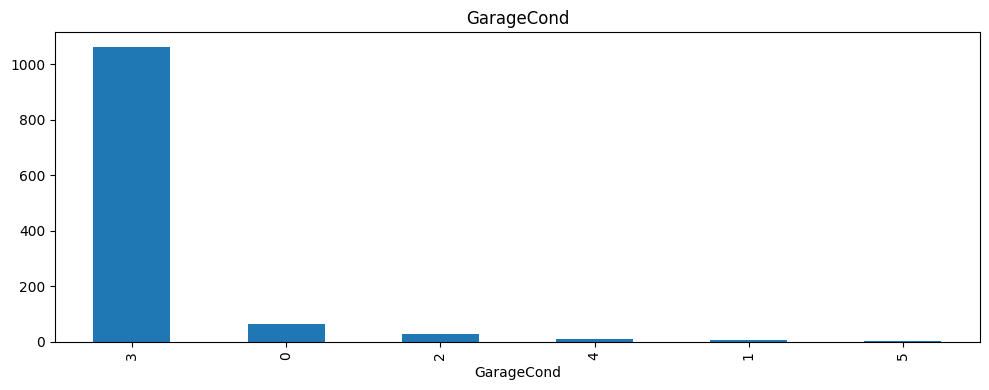

PavedDrive
Y    1070
N      73
P      25
Name: count, dtype: int64


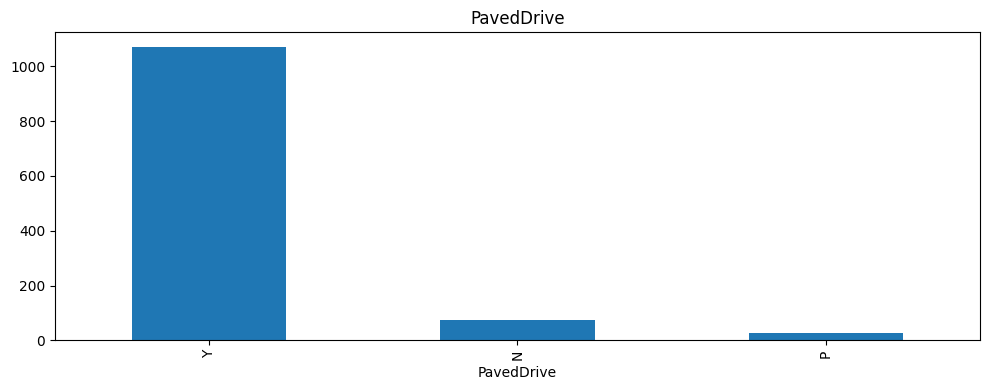

PoolQC
0    1162
2       2
5       2
4       2
Name: count, dtype: int64


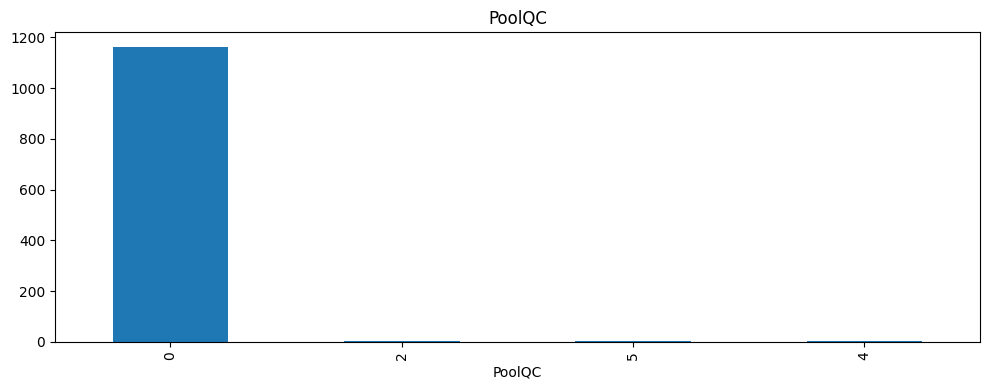

Fence
0    935
3    128
4     50
2     46
1      9
Name: count, dtype: int64


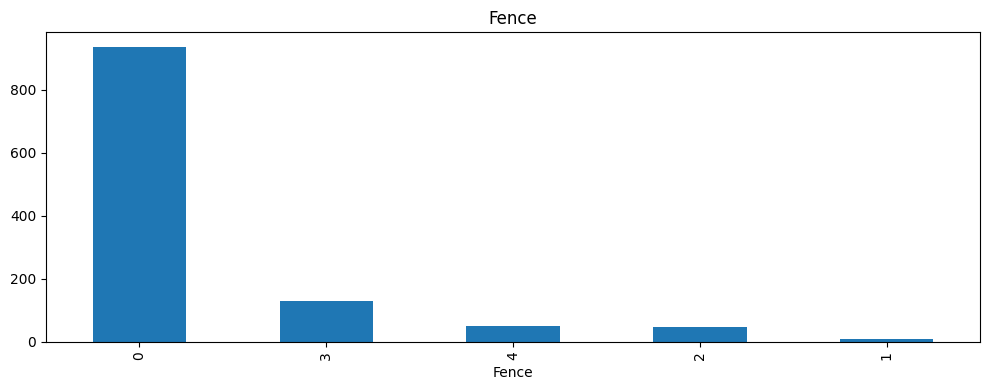

MiscFeature
Shed    41
Othr     2
Gar2     2
TenC     1
Name: count, dtype: int64


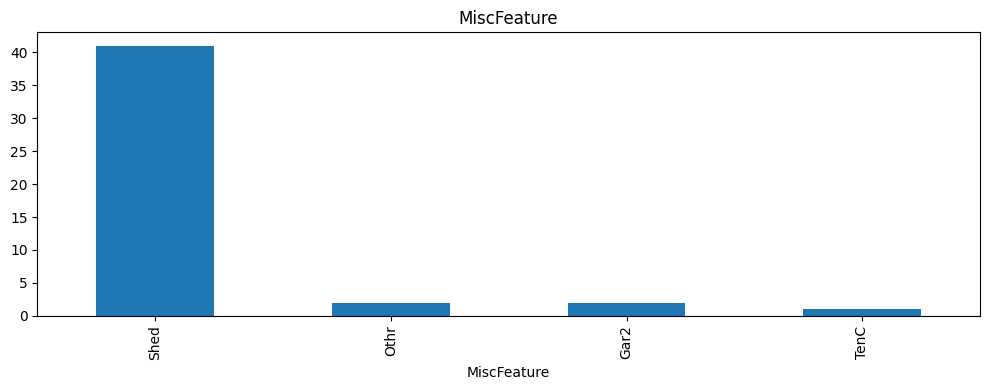

SaleType
WD       1012
New        97
COD        36
ConLD       7
ConLI       4
CWD         4
ConLw       4
Oth         2
Con         2
Name: count, dtype: int64


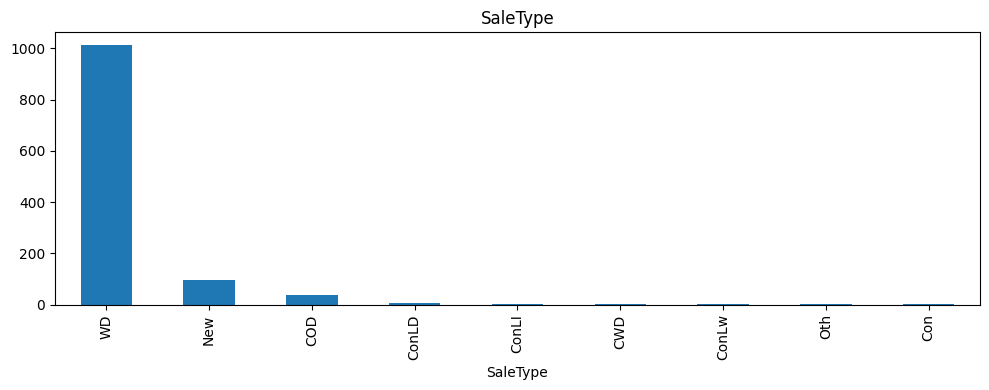

SaleCondition
Normal     964
Partial     98
Abnorml     77
Family      18
Alloca       7
AdjLand      4
Name: count, dtype: int64


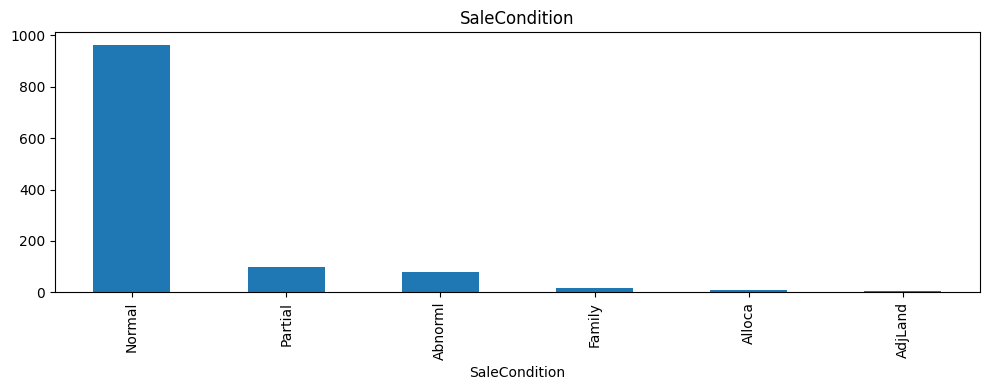

In [78]:
# import matplotlib.pyplot as plt

# for col in cat_cols:
#     print(X_train[col].value_counts())
    
#     plt.figure(figsize=(10, 4))
#     X_train[col].value_counts().plot(kind='bar')
#     plt.title(f'{col}')
#     plt.tight_layout()
#     plt.show()

In [79]:
X_train.nunique().sort_values()

Alley            2
Street           2
Utilities        2
CentralAir       2
MasVnrType       3
              ... 
TotalBsmtSF    630
1stFlrSF       657
BsmtUnfSF      685
GrLivArea      734
LotArea        890
Length: 79, dtype: int64

In [80]:
missing_freq_num = X_train[ohe_cols].isnull().mean()
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True)

Electrical     0.000856
GarageType     0.054795
MasVnrType     0.584760
Alley          0.936644
MiscFeature    0.960616
dtype: float64

<Axes: >

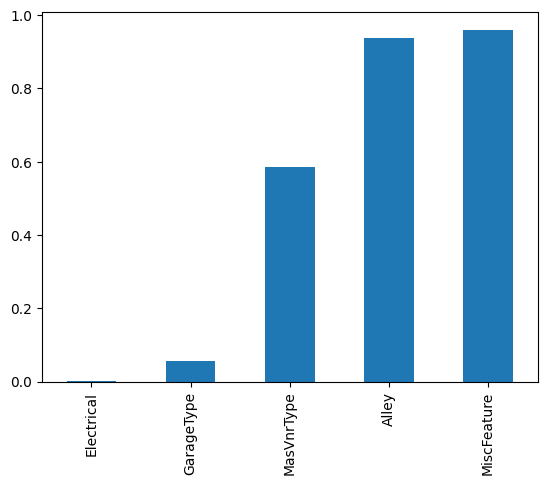

In [81]:
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True).plot(kind="bar")

In [83]:
mode_electrical = X_train["Electrical"].mode()[0]
X_train["Electrical"] = X_train["Electrical"].fillna(mode_electrical)
X_test["Electrical"] = X_test["Electrical"].fillna(mode_electrical)

X_train["MasVnrType"] = X_train["MasVnrType"].fillna("NA")
X_test["MasVnrType"] = X_test["MasVnrType"].fillna("NA")

X_train["GarageType"] = X_train["GarageType"].fillna("NA")
X_test["GarageType"] = X_test["GarageType"].fillna("NA")

X_train["Alley"] = X_train["Alley"].fillna("NA")
X_test["Alley"] = X_test["Alley"].fillna("NA")

X_train["MiscFeature"] = X_train["MiscFeature"].fillna("NA")
X_test["MiscFeature"] = X_test["MiscFeature"].fillna("NA")

In [84]:
missing_freq_num = X_train[ohe_cols].isnull().mean()
missing_freq_num[missing_freq_num > 0].sort_values(ascending=True)

Series([], dtype: float64)

In [85]:
X_train = pd.get_dummies(
    X_train,
    columns=ohe_cols,
    drop_first=True, 
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=ohe_cols,
    drop_first=True,
    dtype=int
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.head()
X_test.head()

,MSSubClass,LotFrontage,LotArea,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
892,20,70.0,8414,0,6,8,1963,2003,0.0,3,...,0,0,0,0,1,0,0,0,0,0
1105,60,98.0,12256,0,8,5,1994,1995,362.0,4,...,1,0,0,0,0,0,0,0,0,0
413,30,56.0,8960,0,5,6,1927,1950,0.0,3,...,0,0,1,0,0,0,0,0,0,0
522,50,50.0,5000,0,6,7,1947,1950,0.0,3,...,0,0,0,0,0,0,0,0,0,0
1036,20,89.0,12898,0,9,5,2007,2008,70.0,4,...,0,0,0,0,0,0,0,0,1,0


In [86]:
list(num_cols)

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

# Feature Engineering

In [87]:
X_train["TotalSF"] = (
    X_train["1stFlrSF"] +
    X_train["2ndFlrSF"] +
    X_train["TotalBsmtSF"]
)

X_test["TotalSF"] = (
    X_test["1stFlrSF"] +
    X_test["2ndFlrSF"] +
    X_test["TotalBsmtSF"]
)

total_bath = (
    X_train["FullBath"] +
    0.5 * X_train["HalfBath"] +
    X_train["BsmtFullBath"] +
    0.5 * X_train["BsmtHalfBath"]
)

X_train["TotalBathPerArea"] = total_bath / X_train["TotalSF"].replace(0, np.nan)
X_train["TotalBathPerArea"] = X_train["TotalBathPerArea"].fillna(0)

total_bath_test = (
    X_test["FullBath"] +
    0.5 * X_test["HalfBath"] +
    X_test["BsmtFullBath"] +
    0.5 * X_test["BsmtHalfBath"]
)

X_test["TotalBathPerArea"] = total_bath_test / X_test["TotalSF"].replace(0, np.nan)
X_test["TotalBathPerArea"] = X_test["TotalBathPerArea"].fillna(0)

X_train["HouseAge"] = X_train["YrSold"] - X_train["YearBuilt"]
X_test["HouseAge"] = X_test["YrSold"] - X_test["YearBuilt"]

X_train["RoomsPerArea"] = X_train["TotRmsAbvGrd"] / X_train["TotalSF"]
X_test["RoomsPerArea"] = X_test["TotRmsAbvGrd"] / X_test["TotalSF"]

X_train["RemodAge"] = X_train["YrSold"] - X_train["YearRemodAdd"]
X_test["RemodAge"] = X_test["YrSold"] - X_test["YearRemodAdd"]

In [88]:
drop_cols = [
    "1stFlrSF",
    "2ndFlrSF",
    "TotalBsmtSF",
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "YrSold",
    "YearBuilt",
    "TotRmsAbvGrd",
    "YearRemodAdd",
    "MiscVal",
    "MoSold",
    "LowQualFinSF",
    "PoolArea"
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

# Feature Selection

In [89]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

features_to_drop = set()

for col in upper.columns:
    if any(upper[col] > 0.65):

        partners = upper.index[upper[col] > 0.65].tolist()

        for partner in partners:
            if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                features_to_drop.add(col)
            else:
                features_to_drop.add(partner)


In [90]:
selected_features = [
    col for col in X_train.columns if col not in features_to_drop
]

print(len(selected_features))
print(len(features_to_drop))

X_train = X_train[selected_features]
X_test = X_test[selected_features]

X_train.head()
X_test.head()

160
33


,MSSubClass,LotFrontage,LotArea,LandSlope,OverallCond,MasVnrArea,ExterCond,BsmtQual,BsmtExposure,BsmtFinType1,...,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,TotalBathPerArea,RoomsPerArea,RemodAge
892,20,70.0,8414,0,8,0.0,3,3,1,6,...,0,0,1,0,0,0,0,0.000705,0.002821,3
1105,60,98.0,12256,0,5,362.0,3,5,3,6,...,0,0,0,0,0,0,0,0.000857,0.002203,15
413,30,56.0,8960,0,6,0.0,3,3,1,1,...,1,0,0,0,0,0,0,0.000491,0.002456,60
522,50,50.0,5000,0,7,0.0,4,3,1,5,...,0,0,0,0,0,0,0,0.000750,0.002624,56
1036,20,89.0,12898,0,5,70.0,3,5,4,6,...,0,0,0,0,0,1,0,0.000926,0.001852,1


In [91]:
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_squared_error 
import numpy as np 
from sklearn.linear_model import LinearRegression 

scaler = StandardScaler() 

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

model = LinearRegression() 
model.fit(X_train_scaled, y_train) 

preds_log = model.predict(X_test_scaled) 
rmse = np.sqrt(mean_squared_error(y_test, preds_log)) 

print("RMSE:", rmse)

RMSE: 0.1543330092651988
